In [2]:
import numpy as np
import matplotlib.pyplot as plt
np.random.seed(2)

In [3]:
X = np.array([[0.50, 0.75, 1.00, 1.25, 1.50, 1.75, 1.75, 2.00, 2.25, 2.50, 
              2.75, 3.00, 3.25, 3.50, 4.00, 4.25, 4.50, 4.75, 5.00, 5.50]])
y = np.array([0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 1, 1, 1, 1, 1])

# extended data 
X = np.concatenate((np.ones((1, X.shape[1])), X), axis = 0)

In [66]:
class Logistic_Regression:
    def __init__(self, eta, max_iter, tol = 1e-4):
        self.eta = eta
        self.max_iter = max_iter
        self.tol = tol
        self.w = None

    def sigmoid(self, z):
        return 1 / (1 + np.exp(-z))

    def fit(self, X, y):
        d, N = X.shape
        self.w = [np.random.rand(d, 1)]
        for _ in range(self.max_iter):
            mix_id = np.random.permutation(N) # randomly shuffle the data
            for i in mix_id:
                xi = X[:, i].reshape(d, 1) # get ith data point
                yi = y[i]
                zi = self.sigmoid(np.dot(self.w[-1].T, xi))
                w_new = self.w[-1] + self.eta*(yi - zi) * xi
                if np.linalg.norm(w_new - self.w[-1]) < self.tol:
                    return self.w[-1]
                self.w.append(w_new)
        return self.w[-1]


In [77]:
eta = .05
model = Logistic_Regression(eta, 10000)
w = model.fit(X, y)
print(w)

[[-4.12524285]
 [ 1.46534537]]


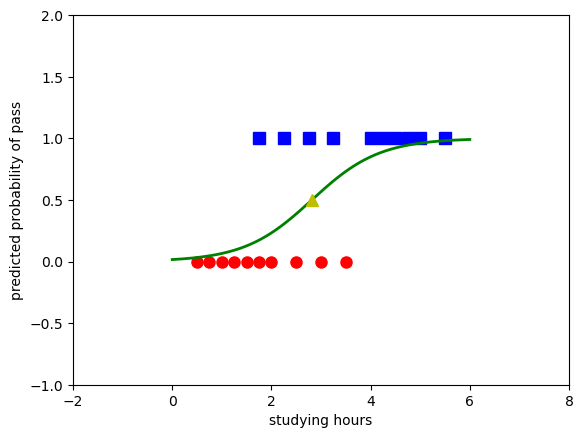

In [78]:
# visualization
X0 = X[1, np.where(y == 0)][0]
y0 = y[np.where(y == 0)]
X1 = X[1, np.where(y == 1)][0]
y1 = y[np.where(y == 1)]

plt.plot(X0, y0, 'ro', markersize = 8)
plt.plot(X1, y1, 'bs', markersize = 8)

xx = np.linspace(0, 6, 1000)
w0 = w[0][0]
w1 = w[1][0]
threshold = -w0/w1
yy = model.sigmoid(w0 + w1*xx)
plt.axis([-2, 8, -1, 2])
plt.plot(xx, yy, 'g-', linewidth = 2)
plt.plot(threshold, .5, 'y^', markersize = 8)
plt.xlabel('studying hours')
plt.ylabel('predicted probability of pass')
plt.show()

In [81]:
from sklearn.linear_model import LogisticRegression
model = LogisticRegression(C=np.inf, tol=1e-4, max_iter=10000)
model.fit(X.T, y)
print(model.coef_, model.intercept_)
print(model.score(X.T, y))

[[-2.03966076  1.5051666 ]] [-2.03966076]
0.8
